In [12]:
# Add src to path to allow importing net_epistemology without installing the package
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [13]:
from net_epistemology.utils.imports import *
from net_epistemology.core.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

In [3]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../data/empirical_networks/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../data/empirical_networks/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


In [6]:
# n_agents = 1000
# my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

## Try with Bayes Agent (Vectorized)

In [4]:
# import dill
# import os
# # Load empirical network
# with open('../data/empirical_networks/pud_final.pkl', 'rb') as f:
#     my_network = dill.load(f)


In [5]:
# import pickle
# import os

# # Load empirical network
# with open('../data/empirical_networks/pud_final.pkl', 'rb') as f:
#     my_network = pickle.load(f)

In [7]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 10000/10000 [00:03<00:00, 3207.93it/s]


steps:  10000
conclusion:  0.21474358974358973
conclusion core 0.3088235294117647


,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,0.770681,0.393160,0.115655,0.849127,0.834014,0.347740,0.06738,0.784325,0.935391,0.876388,...,0.196246,0.667666,0.850078,0.844000,0.049692,0.883098,0.443939,0.616353,0.203147,0.640857
1,0.770681,0.389349,0.115655,0.848099,0.835118,0.349557,0.06738,0.784325,0.935873,0.871989,...,0.196246,0.669439,0.850078,0.846095,0.049692,0.882269,0.443939,0.618243,0.203147,0.633459
2,0.772092,0.381768,0.115655,0.850149,0.836217,0.349557,0.06738,0.784325,0.936351,0.871989,...,0.197511,0.671207,0.848027,0.850216,0.049692,0.879753,0.443939,0.616353,0.203147,0.629737


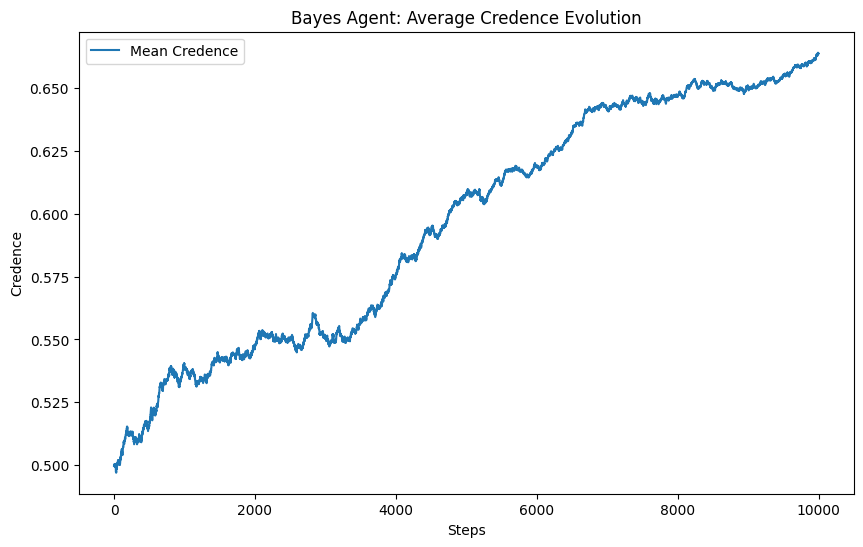

In [8]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [9]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,variance_stopping = False,directed_network = True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

100%|██████████| 10000/10000 [00:05<00:00, 1934.33it/s]


steps:  10000
conclusion:  0.625


,0,1,2,3,4,5,6,7,8,9,...,302,303,304,305,306,307,308,309,310,311
0,"[0.5961852610627738, 0.45550965015735384]","[0.5798795559777724, 0.0001984362514335619]","[0.584575384460447, 0.5869629010217122]","[0.36677031641484553, 0.17793961405476327]","[0.9470301129350686, 0.36091798796619073]","[0.7670988990579599, 0.6589859945042684]","[0.6199598799495742, 0.9999990493381083]","[0.07278754080514328, 0.1137684289633034]","[0.5342669499607511, 0.7729023777118875]","[0.991537906110242, 0.09164753340659676]",...,"[0.9778007020876633, 0.2618182400607587]","[0.8838978450431718, 0.0020827926570341653]","[0.22734648104092509, 0.020847423713042074]","[0.6830190395828694, 0.008140043170024744]","[0.973163959500787, 0.9968795423918743]","[0.9280562082490484, 2.330116209755164e-06]","[0.801200873342217, 0.31354341736255154]","[0.4117483022519861, 0.9492444211475919]","[0.5067069091688605, 0.1699007365661578]","[0.8141475748166821, 0.16287396110808613]"
1,"[0.20844524492857763, 0.3861210375959781]","[0.47254271509932955, 0.15120444994849536]","[0.3285294155041187, 0.5392468375815491]","[0.4088523785859767, 0.6017660671588543]","[0.4848734317823739, 0.49757842824112436]","[0.5881864929614131, 0.3477069523413023]","[0.5962038924137899, 0.5813291700981312]","[0.4325999731167715, 0.355963538864948]","[0.1471211864691909, 0.3548189571387488]","[0.385460410301707, 0.4124801928064312]",...,"[0.4838904608894758, 0.6113967186756605]","[0.4782419814533053, 0.01691103464542508]","[0.5194857714019887, 0.5531749118952579]","[0.25133825571618224, 0.3251404149001737]","[0.005598168604748359, 0.34901614102270084]","[0.8274405149025513, 0.023389249725371153]","[0.6988860159598974, 0.4022026838832011]","[0.6050352035698844, 0.7316771022263855]","[0.39218857931903844, 0.39227351507852015]","[0.3739277337717152, 0.5362746961090495]"
2,"[0.2693241649313805, 0.4589683412207015]","[0.6586270102237278, 0.4193725714412987]","[0.7356143050220909, 0.5015764221682087]","[0.31593212715012303, 0.29122870279359]","[0.6693772647094215, 0.7389235243282205]","[0.3394126193784649, 0.6537382828255722]","[0.4399093399559327, 0.449975268943128]","[0.3858322072147793, 0.5044513152912765]","[0.37894789183704847, 0.5507511582788076]","[0.4097857310963918, 0.45102888594642715]",...,"[0.5727621093343458, 0.5611847811911774]","[0.3844103361142689, 0.10613163769116424]","[0.5471723216259153, 0.35781992205573016]","[0.4580708243347961, 0.5084091864615959]","[0.10278568533829387, 0.5022437700551571]","[0.4494215313133453, 0.034753657404700516]","[0.7037774318798166, 0.6325549001675479]","[0.46989833268148723, 0.7841383037647324]","[0.5812578625591945, 0.6772247802530301]","[0.4526842578529084, 0.6143761814405566]"


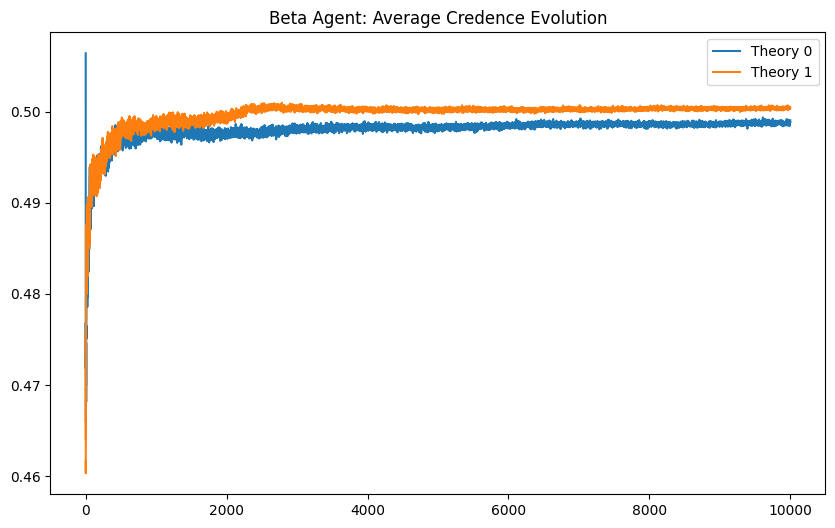

In [10]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

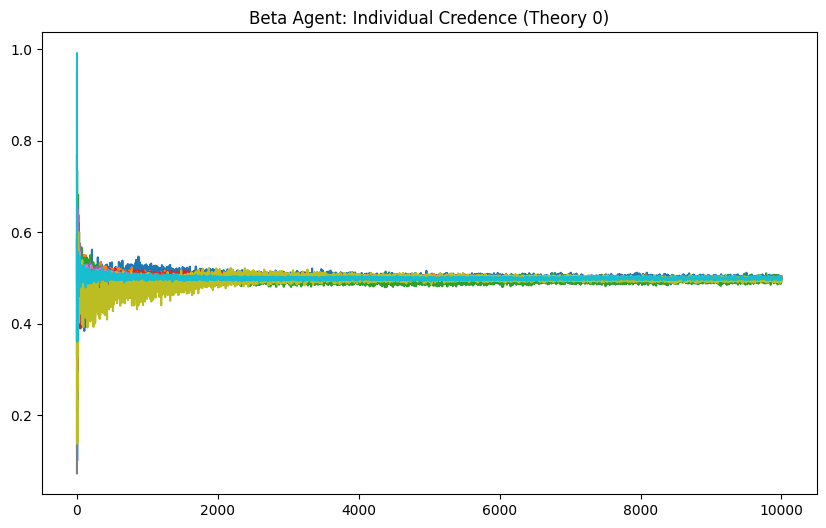

In [11]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()